# 02_How_IaaS_PaaS_and_PPC_FaaS_Actually_Work

There we compared **who manages which layer**. Here we focus on **how they work inside the VPC**, using the idea shown in the screenshots:

* A **VPC** (Virtual Private Cloud) as the outer big red box.
* **Subnets** as the inner red ring.
* Inside we place **VMs**, **PaaS instances (Beanstalk)**, or **Serverless functions**.

---

## 1. VPC, Subnets, and Shared Concepts

Before splitting into IaaS / PaaS / Serverless, understand the common building blocks.

### 1.1 VPC (Virtual Private Cloud)

A **VPC** is your own logically isolated network inside the cloud provider:

* You choose its **IP range** (e.g., `10.0.0.0/16`).
* It is isolated from other customers.
* You can connect it to:

  * The public internet (via an Internet Gateway).
  * Your data center (via VPN or Direct Connect).
  * Other VPCs (via VPC peering).

Think of it as **your private data center drawn as a big red box in the cloud**.

### 1.2 Subnets

Inside a VPC you create **subnets**:

* Each subnet has a smaller IP range (e.g., `10.0.1.0/24`).
* You usually separate **public subnets** (can reach the internet) and **private subnets** (only internal).
* Subnets live in specific **Availability Zones** for high availability.

In the diagram, the **inner red ring** labelled *Subnets* shows this smaller internal network where your resources (VMs, PaaS apps, functions) actually sit.

---

## 2. How IaaS Works – Inside the VPC


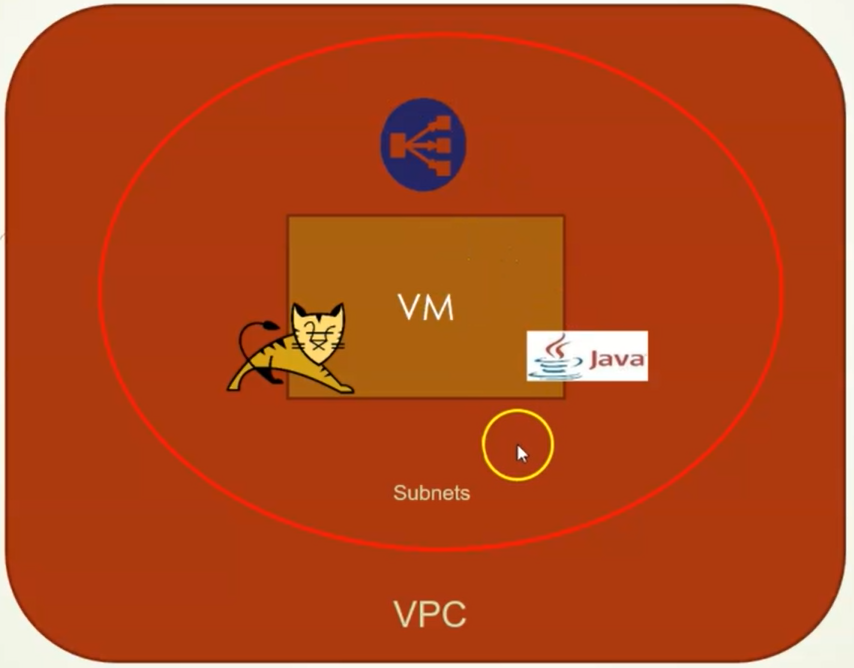

In the IaaS slide, inside the subnet ring you see:

* A **VM box** (virtual machine).
* A **Tomcat cat logo** (application server) on top of the VM.
* A **Java logo** (runtime) near it.

This captures the idea that with IaaS, **you build the full software stack on top of a VM**.

### 2.1 IaaS Stack in Detail

1. **Cloud provider** gives you:

   * VPC + subnets + routing + security groups.
   * A virtual machine (EC2, GCE, Azure VM) with chosen CPU/RAM/disk.

2. **You (customer)** then:

   * Install an **Operating System** (if not preinstalled) – e.g., Ubuntu.
   * Install **middleware** – e.g., Apache Tomcat.
   * Install **runtime** – e.g., Java (JDK).
   * Deploy your **application** – e.g., a Java WAR or Spring Boot JAR.

The slide shows this visually: the VM box with Tomcat and Java icons represents the full stack you manage.

### 2.2 Network Path: From User to VM

1. User visits `https://myapp.example.com`.
2. DNS points that domain to a **load balancer** or directly to the VM’s public IP in your VPC.
3. Traffic enters the VPC, passes through security groups and network ACLs.
4. Request reaches the VM in a subnet.
5. Inside the VM:

   * OS routes it to Tomcat (port 8080 or 80).
   * Tomcat uses the Java runtime to invoke your web application.
   * Application reads/writes data (DB, cache).

### 2.3 Responsibilities in IaaS

You are responsible for:

* OS patching and security updates.
* Installing and updating Java, Tomcat, and other software.
* Managing logs, monitoring, scaling (manual or via scripts/auto‑scaling groups).

Cloud provider is responsible for:

* Physical data center, hardware, hypervisor.
* Basic network reliability and VM lifecycle (start/stop/restart).

### 2.4 Example Scenario (IaaS)

**Example:** Deploying a Java Spring Boot application.

* You launch an EC2 instance in `10.0.1.0/24` subnet.
* SSH into it, install OpenJDK 17.
* Install and configure Apache Tomcat.
* Copy `myapp.war` into Tomcat’s `webapps` directory.
* Configure auto‑scaling group to add more VMs when CPU > 70%.

All of this is your responsibility: you **own the VM**.

---

## 3. How PaaS Works – Beanstalk Instance in a Subnet

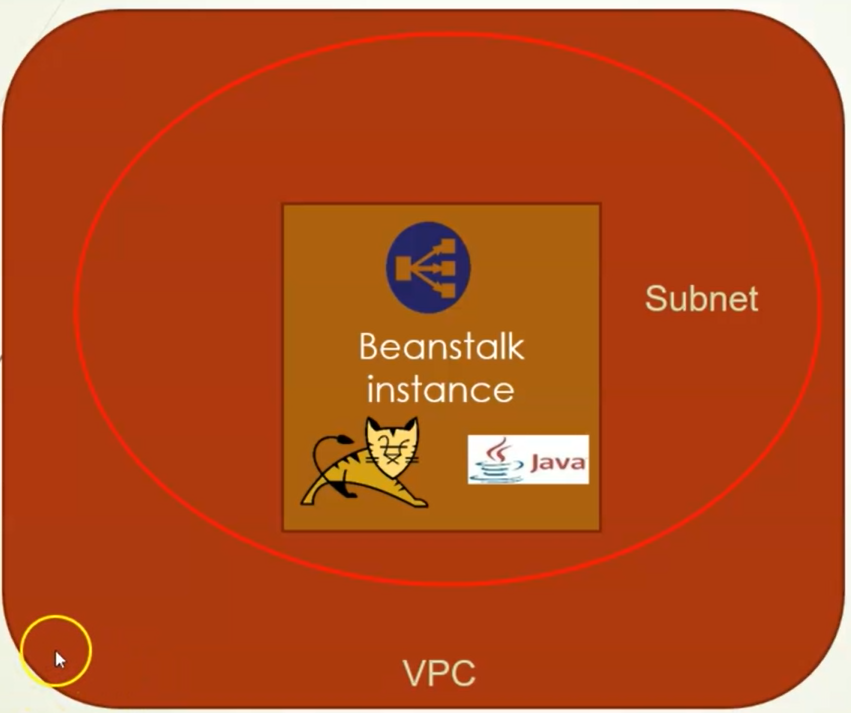

In the PaaS slide you see:

* Same big **VPC box**.
* Same **subnet ring**.
* But inside the subnet there is a single big box labelled **"Beanstalk instance"** with Tomcat + Java logos.

This shows that the **PaaS platform bundles the VM, OS, Tomcat, and Java into one managed block**.

### 3.1 What PaaS Abstracts Away

With PaaS (Elastic Beanstalk, Heroku, App Engine, etc.):

* The platform automatically:

  * Creates underlying VMs/containers in subnets.
  * Installs and configures OS, web server, Java/Tomcat, monitoring, log rotation.
  * Sets up load balancing and auto‑scaling (if configured).

* You only:

  * Upload your **application package** (JAR/WAR or source code).
  * Configure environment variables and scaling rules.

That’s why the diagram shows **one big orange PaaS box** instead of separate VM + Tomcat + Java.

### 3.2 PaaS Lifecycle of a Deploy

1. You run a command or push code (e.g., `eb deploy`, `git push heroku main`).

2. The PaaS platform:

   * Builds your app (if needed).
   * Creates or updates one or more **application instances** (containers/VMs) in subnets.
   * Updates load balancer to point to new instances.
   * Gradually swaps traffic from old version to new version.

3. If traffic increases:

   * Auto‑scaling rules trigger.
   * Platform adds more instances inside subnets.

### 3.3 Responsibilities in PaaS

You:

* Write application code.
* Define scaling policies and environment configuration.
* Handle application‑level logic and data.

Platform:

* Manages VMs, OS, runtime, patches, scaling, health checks.

### 3.4 Example Scenario (PaaS)

Using **AWS Elastic Beanstalk** for a Java/Tomcat app:

* Choose platform: "Java with Tomcat".
* Upload your `myapp.war`.
* Beanstalk creates an environment:

  * VPC + subnets (or uses existing ones).
  * EC2 instances grouped in an Auto Scaling Group.
  * Application Load Balancer.
  * CloudWatch alarms and logs.
* You now access `http://myapp-env.elasticbeanstalk.com` to reach your app.

Compared to IaaS, notice:

* You never SSH to install Java/Tomcat.
* The orange Beanstalk box in the subnet **represents all this hidden infrastructure**.

---

## 4. How PPC / FaaS Would Look in a Similar Diagram


### 4.1 Visual Model

* Big outer box: **VPC** (same as before).
* Inner ring: **Subnets**.
* Instead of a single VM or Beanstalk box, we would see **many small function blocks** labeled with events or endpoints:

  * `getUserFunction`
  * `createOrderFunction`
  * `resizeImageFunction`

Each function is hosted by the provider in a highly abstracted environment – you don’t see the VM at all.

### 4.2 Where Serverless Functions Actually Run

Under the hood, provider still uses:

* Physical servers.
* Containers or micro‑VMs.
* OS and runtimes.

But:

* They are **shared, ephemeral, and fully managed** by the cloud.
* Functions may run **inside your VPC** (via VPC integration) if they need access to private subnets (databases, internal services).

If drawn, you would have:

* VPC with private subnets (database, caches) and public subnets (API Gateway).
* **API Gateway** or event source at the edge.
* When an event arrives, the platform spins up a **Lambda function instance** within the right subnet (if configured) or in a provider‑managed network that has access to your VPC.

### 4.3 Responsibilities in PPC/FaaS

You:

* Write small functions.
* Define triggers (HTTP, queue, cron, file upload, etc.).
* Configure permissions (IAM roles, access policies).

Provider:

* Manages underlying servers, OS, runtimes.
* Scales functions automatically from 0 to thousands.
* Handles concurrency, isolation, and billing.

### 4.4 Example Scenario (FaaS)

Implementing the same Java logic as before but serverless:

* You create `HandleOrderFunction` written in Java.
* Configure API Gateway route `POST /orders` to trigger this function.
* Optionally attach the function to your VPC so it can talk to an RDS database in a private subnet.
* When user sends a request:

  1. API Gateway receives it.
  2. Gateway invokes `HandleOrderFunction`.
  3. Function spins up in a container with Java runtime.
  4. It runs for a few hundred milliseconds, writes to database, returns response.
  5. Container may be re‑used briefly or destroyed; you pay only for compute time.

---

## 5. Side‑by‑Side: What Changes Inside the Subnet

If you zoom into the subnet ring in each model:

### 5.1 IaaS Subnet View

* Multiple VMs (EC2) each running:

  * OS (Ubuntu/Windows).
  * Tomcat.
  * Java.
  * Your apps.

You manually:

* Patch OS and Tomcat.
* Configure scaling groups.

### 5.2 PaaS Subnet View

* A managed **application environment** (Beanstalk/Heroku dynos/App Service plan):

  * Platform automatically manages EC2/VMs.
  * You see only the “application environment” abstraction.

You:

* Deploy app package.
* Configure environment.

### 5.3 FaaS Subnet View

* No always‑on servers dedicated only to you.
* A **pool of ephemeral containers** is used for your functions.
* Functions appear only when triggered.

You:

* Don’t know how many containers exist; you just configure concurrency limits and memory/time.

---

## 6. Design Trade‑offs Across the Three Models

### 6.1 Control vs. Convenience

* **IaaS**: Maximum control (choose OS, custom agents, low‑level tweaks) but highest operational burden.
* **PaaS**: Balanced; you control the app, platform controls environment.
* **FaaS**: Maximum convenience for deployment and scaling, but limited insight/control into infrastructure.

### 6.2 Cost Model

* **IaaS**: Pay per instance hour/second; cost continues even when idle.
* **PaaS**: Pay per app instance (similar to IaaS) plus managed services overhead.
* **FaaS (PPC)**: Pay per request + execution time; **ideal for bursty or low‑throughput workloads**.

### 6.3 Scaling and Reliability

* **IaaS**: You design auto‑scaling, load balancing, failover.
* **PaaS**: Scaling is easier; platform has built‑in strategies.
* **FaaS**: Scaling is automatic; concurrency is handled by provider.

---